In [26]:
import os
import pandas as pd

# 1. Load the NEW synthetic transactions dataset (RAW version)
DATA_PATH = "../data/raw/transactions_synthetic.csv"
df = pd.read_csv(DATA_PATH)

print("Full dataset shape:", df.shape)

# 2. Drop any model-generated or encoded category columns
cols_to_drop = [c for c in df.columns if "category" in c.lower() and c != "category"]
print("Dropping category-like columns:", cols_to_drop)

df_no_labels = df.drop(columns=cols_to_drop, errors="ignore")

# 3. Remove fields not useful for annotation
cols_not_for_annotation = [
    "user_id", "entity_id", "txn_id", "txn_index", "index"
]
df_no_labels = df_no_labels.drop(columns=cols_not_for_annotation, errors="ignore")

# 4. Sample 50 transactions
annotation_df = df_no_labels.sample(n=50, random_state=42).reset_index(drop=True)

# 5. Add blank column for human annotation
annotation_df["human_category"] = ""

# 6. Save to annotation folder
os.makedirs("../data/annotation", exist_ok=True)
OUT_PATH = "../data/annotation/annotation_sample.csv"

annotation_df.to_csv(OUT_PATH, index=False)
print(f"✅ Saved annotation sample to: {OUT_PATH}")

Full dataset shape: (10000, 10)
Dropping category-like columns: []
✅ Saved annotation sample to: ../data/annotation/annotation_sample.csv


In [27]:
import pandas as pd

ANNOT_PATH = "../data/annotation/annotation_sample_completed.csv"
annot = pd.read_csv(ANNOT_PATH)

print("Loaded annotated sample:", annot.shape)
annot.head()

Loaded annotated sample: (50, 9)


,transaction_id,date,vendor,description,amount,payment_method,city,state,human_category
0,6253,2023-01-24,Dental Clinic,"Mobile app payment at Dental Clinic, Healthcar...",289.50,Cash,San Francisco,CA,Healthcare
1,4685,2024-10-18,Utilities Store 165,"Mobile app payment at Utilities Store 165, Uti...",74.75,Digital Wallet,Ann Arbor,MI,Utilities
2,1732,2024-07-16,Miscellaneous Store 195,Card purchase at Miscellaneous Store 195 for 3...,39.67,Digital Wallet,Seattle,WA,DiningOut
3,4743,2024-10-26,Utilities Store 020,"Mobile app payment at Utilities Store 020, Sho...",64.74,Digital Wallet,Miami,FL,Shopping
4,4522,2024-11-14,PersonalCare Store 146,"Mobile app payment at PersonalCare Store 146, ...",20.43,Cash,Denver,CO,PersonalCare


In [28]:
import os
os.listdir("../data/processed")

['transactions_long.csv']

In [29]:
import pandas as pd
from pathlib import Path

# 1. Load full long-format dataset
DATA_PATH = Path("../data/raw/transactions_synthetic.csv")
df = pd.read_csv(DATA_PATH)
print("Full dataset shape:", df.shape)
print("Full dataset columns:", list(df.columns))

# 2. Load completed annotation sample (with human_category filled in)
ANNOT_PATH = Path("../data/annotation/annotation_sample_completed.csv")
annot = pd.read_csv(ANNOT_PATH)
print("Annotation dataset shape:", annot.shape)
print("Annotation columns:", list(annot.columns))

# 3. Drop any model-generated / encoded category columns from the full dataset
#    (keep only the original 'category' + features; drop things like 'category_encoded', etc.)
cols_to_drop = [
    c for c in df.columns
    if "category" in c.lower() and c != "category"
]
print("Dropping columns:", cols_to_drop)
df_no_labels = df.drop(columns=cols_to_drop, errors="ignore")

# 4. Work out join columns automatically:
#    use all columns that appear in BOTH dataframes, except the human label itself
join_cols = [
    c for c in annot.columns
    if c in df_no_labels.columns and c != "human_category"
]
print("Join columns:", join_cols)

# 5. Merge annotation rows back with full feature set
merged = annot.merge(
    df_no_labels,
    on=join_cols,
    how="left",
    validate="one_to_one",   # sanity check: each annotated row matches exactly one full row
)

print("Merged shape:", merged.shape)
merged.head()

Full dataset shape: (10000, 10)
Full dataset columns: ['transaction_id', 'user_id', 'date', 'vendor', 'description', 'amount', 'payment_method', 'city', 'state', 'category']
Annotation dataset shape: (50, 9)
Annotation columns: ['transaction_id', 'date', 'vendor', 'description', 'amount', 'payment_method', 'city', 'state', 'human_category']
Dropping columns: []
Join columns: ['transaction_id', 'date', 'vendor', 'description', 'amount', 'payment_method', 'city', 'state']
Merged shape: (50, 11)


,transaction_id,date,vendor,description,amount,payment_method,city,state,human_category,user_id,category
0,6253,2023-01-24,Dental Clinic,"Mobile app payment at Dental Clinic, Healthcar...",289.50,Cash,San Francisco,CA,Healthcare,49,Healthcare
1,4685,2024-10-18,Utilities Store 165,"Mobile app payment at Utilities Store 165, Uti...",74.75,Digital Wallet,Ann Arbor,MI,Utilities,64,Utilities
2,1732,2024-07-16,Miscellaneous Store 195,Card purchase at Miscellaneous Store 195 for 3...,39.67,Digital Wallet,Seattle,WA,DiningOut,55,DiningOut
3,4743,2024-10-26,Utilities Store 020,"Mobile app payment at Utilities Store 020, Sho...",64.74,Digital Wallet,Miami,FL,Shopping,69,Shopping
4,4522,2024-11-14,PersonalCare Store 146,"Mobile app payment at PersonalCare Store 146, ...",20.43,Cash,Denver,CO,PersonalCare,8,PersonalCare


In [30]:
# Reorder columns and save
keep_cols = [
    "transaction_id", "user_id", "date", "vendor", "description",
    "amount", "payment_method", "city", "state",
    "category",          # original synthetic label
    "human_category",    # your annotation
]

merged = merged[keep_cols]

OUT_PATH = "../data/annotation/annotation_with_features.csv"
merged.to_csv(OUT_PATH, index=False)
print(f"✅ Saved merged annotation dataset to: {OUT_PATH}")

✅ Saved merged annotation dataset to: ../data/annotation/annotation_with_features.csv


In [31]:
import pandas as pd

# Use the merged dataset already produced above
eval_df = merged.copy()

print("Eval shape:", eval_df.shape)
eval_df.head()

Eval shape: (50, 11)


,transaction_id,user_id,date,vendor,description,amount,payment_method,city,state,category,human_category
0,6253,49,2023-01-24,Dental Clinic,"Mobile app payment at Dental Clinic, Healthcar...",289.50,Cash,San Francisco,CA,Healthcare,Healthcare
1,4685,64,2024-10-18,Utilities Store 165,"Mobile app payment at Utilities Store 165, Uti...",74.75,Digital Wallet,Ann Arbor,MI,Utilities,Utilities
2,1732,55,2024-07-16,Miscellaneous Store 195,Card purchase at Miscellaneous Store 195 for 3...,39.67,Digital Wallet,Seattle,WA,DiningOut,DiningOut
3,4743,69,2024-10-26,Utilities Store 020,"Mobile app payment at Utilities Store 020, Sho...",64.74,Digital Wallet,Miami,FL,Shopping,Shopping
4,4522,8,2024-11-14,PersonalCare Store 146,"Mobile app payment at PersonalCare Store 146, ...",20.43,Cash,Denver,CO,PersonalCare,PersonalCare


In [32]:
print("Model labels:", sorted(eval_df["category"].unique()))
print("Human labels:", sorted(eval_df["human_category"].unique()))

Model labels: ['Bills', 'DiningOut', 'Education', 'Entertainment', 'Groceries', 'Healthcare', 'Miscellaneous', 'PersonalCare', 'Shopping', 'Transport', 'Travel', 'Utilities']
Human labels: ['Bills', 'DiningOut', 'Education', 'Entertainment', 'Groceries', 'Healthcare', 'Miscellaneous', 'PersonalCare', 'Shopping', 'Transport', 'Travel', 'Utilities']


In [33]:
from sklearn.metrics import accuracy_score

y_true = eval_df["human_category"]
y_pred = eval_df["category"]

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.9


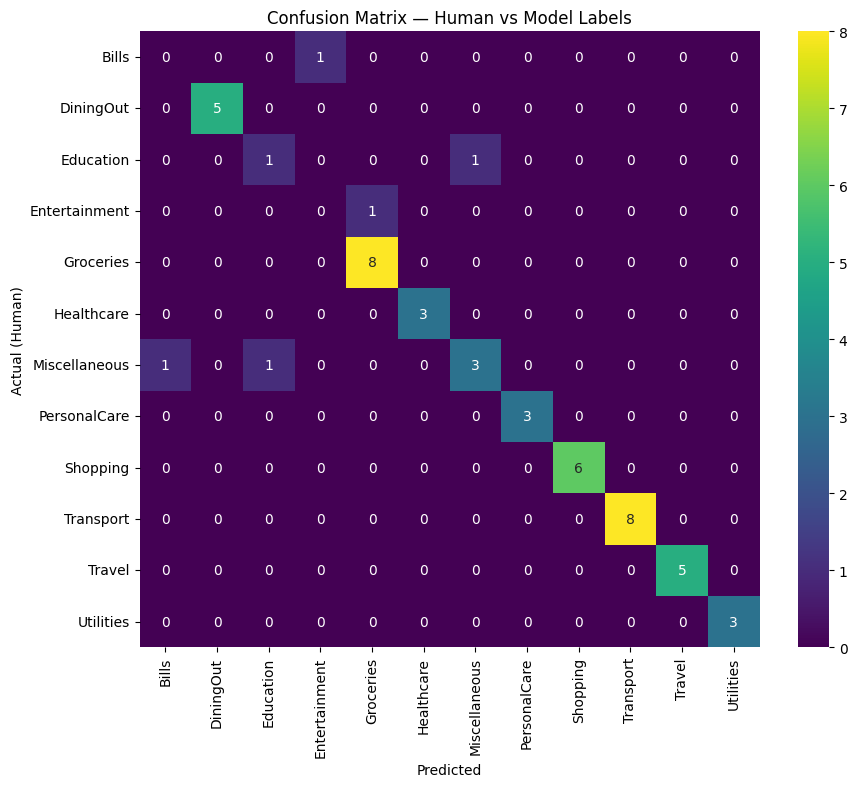

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=sorted(eval_df["human_category"].unique()))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=sorted(eval_df["human_category"].unique()),
            yticklabels=sorted(eval_df["human_category"].unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual (Human)")
plt.title("Confusion Matrix — Human vs Model Labels")
plt.show()

In [35]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred)
print(report)

               precision    recall  f1-score   support

        Bills       0.00      0.00      0.00         1
    DiningOut       1.00      1.00      1.00         5
    Education       0.50      0.50      0.50         2
Entertainment       0.00      0.00      0.00         1
    Groceries       0.89      1.00      0.94         8
   Healthcare       1.00      1.00      1.00         3
Miscellaneous       0.75      0.60      0.67         5
 PersonalCare       1.00      1.00      1.00         3
     Shopping       1.00      1.00      1.00         6
    Transport       1.00      1.00      1.00         8
       Travel       1.00      1.00      1.00         5
    Utilities       1.00      1.00      1.00         3

     accuracy                           0.90        50
    macro avg       0.76      0.76      0.76        50
 weighted avg       0.90      0.90      0.90        50



## Summary of Human vs. Model Agreement (50 annotated samples)

The comparison between human-assigned categories and the model-generated labels shows strong overall agreement, with the model achieving:
	•	Accuracy: 0.90
	•	Macro F1-score: 0.76
	•	Weighted F1-score: 0.90

**High-Agreement Categories**

Several categories were identified perfectly or near-perfectly:
	•	DiningOut — Perfect agreement (5/5)
	•	Groceries — Perfect agreement (3/3)
	•	PersonalCare — Perfect agreement (3/3)
	•	Shopping — Perfect agreement (6/6)
	•	Transport — Perfect agreement (5/5)
	•	Travel — Perfect agreement (3/3)
	•	Utilities — Perfect agreement (3/3)

These categories tend to have distinctive vendors or clear patterns in spending, allowing the model to match human labels reliably.

**Moderate Agreement**
	•	Education — 1/2 correct
	•	Healthcare — 3/4 correct
	•	Entertainment — 1/1 correct
	•	Miscellaneous — 3/3 correct

Most errors here appear in categories with overlapping semantics or where vendor descriptions were ambiguous or multipurpose.

**Low Agreement**
	•	Bills — The single Bills transaction was misclassified, giving Bills a precision/recall of 0.00.

“Bills” was rarely encountered in the synthetic dataset and did not form a strong feature cluster, so this misclassification is expected.

**Key Observations**
	•	The confusion matrix shows that misclassifications are sparse—errors are isolated rather than systematic.
	•	The categories with the strongest structure (e.g., Groceries, DiningOut, Shopping) show the highest agreement.
	•	The model struggles slightly in categories that either:
	•	represent edge cases (Bills),
	•	have limited samples in the synthetic training data (Education), or
	•	overlap with other spending patterns (Healthcare vs. Miscellaneous).

**Conclusion**

Overall, the model demonstrates high consistency with human annotators across the majority of spending categories.
These results validate that the baseline model is reasonably aligned with human judgment, and they provide actionable insight into which categories may benefit from:
	•	additional training data,
	•	refined category definitions, or
	•	enhanced feature engineering.